In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preethikurra/ravdess-tess")

print("Path to dataset files:", path)

100%|██████████| 428M/428M [00:03<00:00, 118MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preethikurra/ravdess-tess/versions/1


In [ ]:
# =========================
# 2. Imports
# =========================
import librosa
import numpy as np
import os

In [ ]:
# =========================
# 3. Label Mapping
# =========================
ravdess_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def get_label(file):
    if "-" in file:
        code = file.split("-")[2]
        return ravdess_map.get(code, "unknown")
    else:
        return file.split("_")[1].replace(".wav", "")

Feature Extraction

In [ ]:
# =========================
# 4. Feature Extraction
# =========================
def extract_features(file_path, max_len=100):
    audio, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc

Load dataset

In [ ]:
# =========================
# 5. Load Dataset
# =========================
data = []
labels = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            features = extract_features(file_path)
            data.append(features)

            label = get_label(file)
            labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Shape:", X.shape, y.shape)

Shape: (4240, 40, 100) (4240,)


In [ ]:
# =========================
# 6. Normalize
# =========================
X = X / np.max(X)

In [ ]:
# =========================
# 7. TRANSPOSE (CRITICAL FIX)
# =========================
X = np.transpose(X, (0, 2, 1))  # (samples, time, features)

Encode labels

In [ ]:
# =========================
# 8. Encode Labels
# =========================
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [ ]:
# =========================
# 9. Train-Test Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

Build BiRNN model

In [ ]:
# =========================
# 10. Strong BiRNN Model
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

model = Sequential()

model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(100, 40)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(y_categorical.shape[1], activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100, 256)       │       173,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 207)            │        13,455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753,359 (2.87 MB)

 Trainable params: 753,359 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

Train

In [ ]:
# =========================
# 11. Train (with EarlyStopping)
# =========================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.0492 - loss: 4.5760 - val_accuracy: 0.0825 - val_loss: 4.1060
Epoch 2/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.0710 - loss: 4.2438 - val_accuracy: 0.0979 - val_loss: 4.0673
Epoch 3/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0687 - loss: 4.2386 - val_accuracy: 0.1144 - val_loss: 4.0334
Epoch 4/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.0843 - loss: 4.1726 - val_accuracy: 0.1026 - val_loss: 4.0195
Epoch 5/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.1002 - loss: 4.1085 - val_accuracy: 0.1050 - val_loss: 3.9789
Epoch 6/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0955 - loss: 4.0258 - val_accuracy: 0.0825 - val_loss: 3.9669
Epoch 7/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.1047 - loss: 3.9100 - val_accuracy: 0.1203 - val_loss: 3.8394
Epoch 8/40
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.1159 - loss: 3.8143 - val_acc

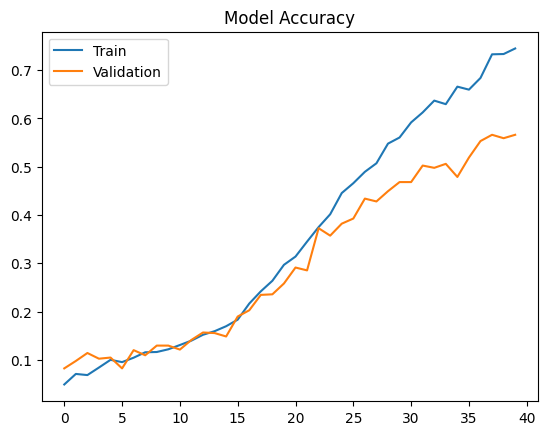

In [ ]:
# =========================
# 12. Plot Accuracy
# =========================
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()